# Recurrent Neural Network (RNN) - PyTorch

Using device: cpu
Epoch 01/15 - loss: 0.6812 - acc: 0.5920 - val_loss: 0.6659 - val_acc: 0.6929
Epoch 02/15 - loss: 0.6489 - acc: 0.6312 - val_loss: 0.6212 - val_acc: 0.5714
Epoch 03/15 - loss: 0.5974 - acc: 0.6491 - val_loss: 0.5595 - val_acc: 0.7714
Epoch 04/15 - loss: 0.5511 - acc: 0.7554 - val_loss: 0.5228 - val_acc: 0.8071
Epoch 05/15 - loss: 0.5117 - acc: 0.7768 - val_loss: 0.4808 - val_acc: 0.7857
Epoch 06/15 - loss: 0.4731 - acc: 0.7991 - val_loss: 0.4350 - val_acc: 0.8286
Epoch 07/15 - loss: 0.4500 - acc: 0.8098 - val_loss: 0.3982 - val_acc: 0.8393
Epoch 08/15 - loss: 0.4262 - acc: 0.8018 - val_loss: 0.3821 - val_acc: 0.8464
Epoch 09/15 - loss: 0.4084 - acc: 0.8116 - val_loss: 0.3618 - val_acc: 0.8357
Epoch 10/15 - loss: 0.4100 - acc: 0.8063 - val_loss: 0.3660 - val_acc: 0.8393
Epoch 11/15 - loss: 0.3894 - acc: 0.8161 - val_loss: 0.3616 - val_acc: 0.8214
Epoch 12/15 - loss: 0.3918 - acc: 0.8116 - val_loss: 0.3515 - val_acc: 0.8357
Epoch 13/15 - loss: 0.3907 - acc: 0.8170 - val

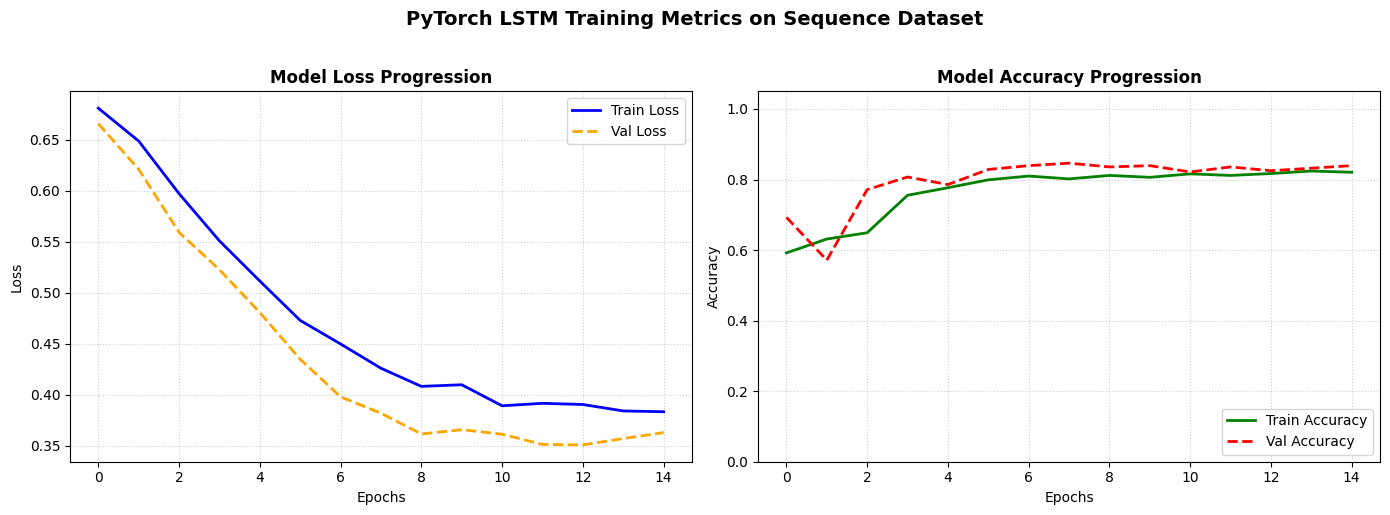

In [2]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# ── 0. REPRODUCIBILITY & SETUP ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 1. DATA PREPARATION ───────────────────────────────────────────────────────
samples, seq_len, features = 1400, 30, 3

# Synthetic sequence dataset: class 1 has stronger late positive signal.
X = np.random.normal(size=(samples, seq_len, features)).astype("float32")
signal = X[:, -10:, 0].mean(axis=1) + 0.5 * X[:, :10, 1].mean(axis=1)
y = (signal > 0.05).astype("int64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=64,
    shuffle=True,
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=64,
    shuffle=False,
)

# ── 2. MODEL ARCHITECTURE (Upgraded to LSTM) ──────────────────────────────────
class SequenceClassifier(nn.Module):
    def __init__(self, input_dim: int = 3, hidden_dim: int = 32):
        super().__init__()
        # LSTM is vastly superior to vanilla RNN for sequences of length 30
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        # lstm_out shape: (batch, seq_len, hidden_dim)
        lstm_out, (hidden_state, cell_state) = self.lstm(x)

        # We only care about the output at the final time step
        last_timestep_out = lstm_out[:, -1, :]

        out = self.dropout(last_timestep_out)
        return self.classifier(out)

model = SequenceClassifier().to(device)

# ── 3. TRAINING PIPELINE ──────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 15
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()

    history["loss"].append(running_loss / total)
    history["accuracy"].append(correct / total)

    # --- Validation Phase ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_x.size(0)
            _, predicted = outputs.max(1)
            val_total += batch_y.size(0)
            val_correct += predicted.eq(batch_y).sum().item()

    history["val_loss"].append(val_loss / val_total)
    history["val_accuracy"].append(val_correct / val_total)

    print(f"Epoch {epoch+1:02d}/{epochs} - "
          f"loss: {history['loss'][-1]:.4f} - acc: {history['accuracy'][-1]:.4f} - "
          f"val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_accuracy'][-1]:.4f}")

# ── 4. VISUALIZATION PIPELINE ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1.plot(history["loss"], label="Train Loss", color="blue", lw=2)
ax1.plot(history["val_loss"], label="Val Loss", color="orange", lw=2, linestyle="--")
ax1.set_title("Model Loss Progression", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend(frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Accuracy curves
ax2.plot(history["accuracy"], label="Train Accuracy", color="green", lw=2)
ax2.plot(history["val_accuracy"], label="Val Accuracy", color="red", lw=2, linestyle="--")
ax2.set_title("Model Accuracy Progression", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.05)
ax2.legend(frameon=True, loc="lower right")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("PyTorch LSTM Training Metrics on Sequence Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


Starting training on Sequential MNIST...
Epoch 01/10 - loss: 0.4444 - acc: 0.8536 - val_loss: 0.1089 - val_acc: 0.9672
Epoch 02/10 - loss: 0.1008 - acc: 0.9707 - val_loss: 0.0850 - val_acc: 0.9752
Epoch 03/10 - loss: 0.0705 - acc: 0.9801 - val_loss: 0.0590 - val_acc: 0.9819
Epoch 04/10 - loss: 0.0571 - acc: 0.9832 - val_loss: 0.0547 - val_acc: 0.9836
Epoch 05/10 - loss: 0.0474 - acc: 0.9859 - val_loss: 0.0478 - val_acc: 0.9862
Epoch 06/10 - loss: 0.0383 - acc: 0.9886 - val_loss: 0.0537 - val_acc: 0.9842
Epoch 07/10 - loss: 0.0354 - acc: 0.9896 - val_loss: 0.0507 - val_acc: 0.9858
Epoch 08/10 - loss: 0.0300 - acc: 0.9913 - val_loss: 0.0493 - val_acc: 0.9872
Epoch 09/10 - loss: 0.0290 - acc: 0.9910 - val_loss: 0.0417 - val_acc: 0.9886
Epoch 10/10 - loss: 0.0237 - acc: 0.9930 - val_loss: 0.0431 - val_acc: 0.9865


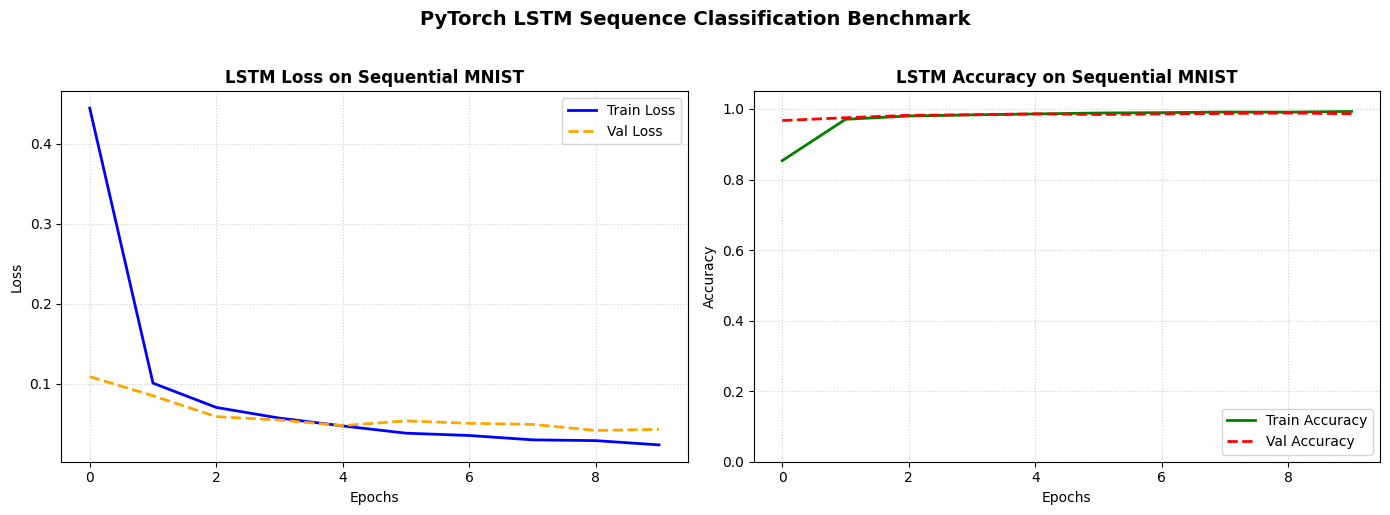

In [1]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# ── 0. REPRODUCIBILITY & SETUP ────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── 1. DATA PREPARATION (Sequential MNIST) ────────────────────────────────────
# We use the standard MNIST dataset, but we will treat it as sequence data
# Image size is 28x28. We treat it as 28 sequences (rows) of 28 features (pixels).

# Standard normalization for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load the authentic datasets
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ── 2. MODEL ARCHITECTURE ─────────────────────────────────────────────────────
class SequenceMNISTClassifier(nn.Module):
    def __init__(self, input_dim=28, hidden_dim=128, num_layers=2, num_classes=10):
        super().__init__()
        self.input_dim = input_dim
        self.seq_len = 28

        # A 2-layer LSTM for stronger sequence memory
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 # Dropout between LSTM layers
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # Input shape from DataLoader: (batch, channels=1, height=28, width=28)
        # We need to reshape it to: (batch, seq_len=28, features=28)
        x = x.squeeze(1)

        # lstm_out shape: (batch, seq_len, hidden_dim)
        lstm_out, (hidden_state, cell_state) = self.lstm(x)

        # Extract the output from the final time step
        last_timestep_out = lstm_out[:, -1, :]

        out = self.dropout(last_timestep_out)
        return self.classifier(out)

model = SequenceMNISTClassifier().to(device)

# ── 3. TRAINING PIPELINE ──────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 10
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

print("Starting training on Sequential MNIST...")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_x.size(0)
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()

    history["loss"].append(running_loss / total)
    history["accuracy"].append(correct / total)

    # --- Validation Phase ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item() * batch_x.size(0)
            _, predicted = outputs.max(1)
            val_total += batch_y.size(0)
            val_correct += predicted.eq(batch_y).sum().item()

    history["val_loss"].append(val_loss / val_total)
    history["val_accuracy"].append(val_correct / val_total)

    print(f"Epoch {epoch+1:02d}/{epochs} - "
          f"loss: {history['loss'][-1]:.4f} - acc: {history['accuracy'][-1]:.4f} - "
          f"val_loss: {history['val_loss'][-1]:.4f} - val_acc: {history['val_accuracy'][-1]:.4f}")

# ── 4. VISUALIZATION PIPELINE ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
ax1.plot(history["loss"], label="Train Loss", color="blue", lw=2)
ax1.plot(history["val_loss"], label="Val Loss", color="orange", lw=2, linestyle="--")
ax1.set_title("LSTM Loss on Sequential MNIST", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Loss")
ax1.legend(frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Accuracy curves
ax2.plot(history["accuracy"], label="Train Accuracy", color="green", lw=2)
ax2.plot(history["val_accuracy"], label="Val Accuracy", color="red", lw=2, linestyle="--")
ax2.set_title("LSTM Accuracy on Sequential MNIST", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.0, 1.05)
ax2.legend(frameon=True, loc="lower right")
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle("PyTorch LSTM Sequence Classification Benchmark", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()